In [1]:
# MÓDULOS E IMPORTAÇÕES
import kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns       # Referência de estudo: https://www.dannidanliu.com/introduction-to-s/

from datetime import date, datetime

In [2]:
# Loading data
file = 'air traffic.csv'
df_original = pd.read_csv(f'data\{file}')

In [ ]:
# Processing data
df = df_original.copy()

df = df[['Year', 'Month', 'Flt']]

df['date'] = pd.to_datetime(df[['Year', 'Month']].assign(day=1))

df['flights'] = df['Flt'].str.replace(',', '').astype('Int32')

df = df.drop(columns=['Year', 'Month', 'Flt'])

df = df.sort_values('date')#.set_index('Date')


In [ ]:
df

In [ ]:
df['flights'].describe()

# Data Visualization

In [ ]:
f, (ax_plot, ax_hist, ax_box) = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 3))

sns.lineplot(x = df['date'], y = df['flights'], ax=ax_plot)
sns.histplot(y = df['flights'], ax=ax_hist)
sns.boxplot(df['flights'], ax=ax_box)

In [ ]:
# Segmentação temporal

df_2003_to_2008 = df[df['date'] <= '2008-08-01']
df_2008_to_2019 = df[('2008-08-01' < df['date']) & (df['date'] <= '2019-12-01')]
df_2020_to_2023 = df['2019-12-01' < df['date']]

In [ ]:
sns.lineplot(x=df_2003_to_2008['date'], y=df_2003_to_2008['flights'], label="2003 to 2008")
sns.lineplot(x=df_2008_to_2019['date'], y=df_2008_to_2019['flights'], label="2008 to 2019")
sns.lineplot(x=df_2020_to_2023['date'], y=df_2020_to_2023['flights'], label="2020 to 2023")


In [ ]:
sns.histplot(
    {"2003 to 2008": df_2003_to_2008['flights'], 
     "2008 to 2019": df_2008_to_2019['flights'], 
     "2020 to 2023": df_2020_to_2023['flights']
    }, 
)

In [ ]:
sns.boxplot(
    {"2003 to 2008": df_2003_to_2008['flights'], 
     "2008 to 2019": df_2008_to_2019['flights'], 
     "2019 to 2023": df_2020_to_2023['flights']
    }, 
)

# Linear Regression Models

In [ ]:
# Processing data for training for different hyperparameters

def process_historical_data(df, K):

    X = pd.DataFrame()
    
    for i in range(1, K + 1):
        v = df['flights'].rename(f'x_{i}').shift(i)
        X = pd.concat([X, v], axis=1)

    y = df.copy()
    y.rename(columns={'flights': 'y'}, inplace=True)

    df_processed = pd.concat([y, X], axis=1).dropna().reset_index(drop=True)  # for dropping redundant rows with null values

    return df_processed

In [160]:
K = 2
df_processed = process_historical_data(df, K)

In [161]:
df_2003_to_2008 = df_processed[df_processed['date'] <= '2008-08-01']
df_2008_to_2019 = df_processed[('2008-08-01' < df_processed['date']) & (df_processed['date'] <= '2019-12-01')]
df_2020_to_2023 = df_processed['2019-12-01' < df_processed['date']]

# Division between testing and training data
df_train_and_validation = pd.concat([df_2003_to_2008, df_2008_to_2019])
df_test = df_2020_to_2023

# Division between training and validation data

# df must be sorted chronologically!
# 80 % for training and 20 % for validation
split_index = int(len(df_train_and_validation) * 0.8)

df_train = df_train_and_validation.iloc[:split_index]   # 163 rows × 1 columns
df_valid = df_train_and_validation.iloc[split_index:]   #  41 rows × 1 columns

In [162]:
X_train = df_train.drop(columns=['date','y'])
y_train = df_train['y']

X_valid = df_valid.drop(columns=['date','y'])
y_valid = df_valid['y']

In [163]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [164]:
y_pred = pd.Series(model.predict(X_valid))

In [166]:
df_result = pd.concat(
    [y_valid.rename('y').reset_index(drop=True), 
     y_pred.rename('ŷ = f(x,θ)').astype(int).reset_index(drop=True)],  # deliberadamente converti a previsão para um número inteiro. 
    axis = 1
)

df_result.insert(0, 'date', df_valid['date'].reset_index(drop=True))

df_result['ϵ = y - ŷ'] = df_result['y'] - df_result['ŷ = f(x,θ)']
df_result['|ϵ|'] = abs(df_result['ϵ = y - ŷ'])
df_result['ϵ²'] = df_result['ϵ = y - ŷ']*df_result['ϵ = y - ŷ']
df_result['ϵr = 1 - ŷ/y'] = df_result['ϵ = y - ŷ']/df_result['y']
df_result['|er|'] = abs(df_result['ϵr = 1 - ŷ/y'])
df_result['100% × |er|'] = df_result['|er|'].map('{:.2%}'.format)

display(df_result.head())
display(df_result.drop(columns='date').describe())

,date,y,"ŷ = f(x,θ)",ϵ = y - ŷ,|ϵ|,ϵ²,ϵr = 1 - ŷ/y,|er|,100% × |er|
0,2016-08-01,806894,803050,3844,3844,14776336,0.004764,0.004764,0.48%
1,2016-09-01,735933,809687,-73754,73754,5439652516,-0.100218,0.100218,10.02%
2,2016-10-01,751607,775005,-23398,23398,547466404,-0.031131,0.031131,3.11%
3,2016-11-01,719350,755482,-36132,36132,1305521424,-0.050229,0.050229,5.02%
4,2016-12-01,734434,746163,-11729,11729,137569441,-0.01597,0.01597,1.60%


,y,"ŷ = f(x,θ)",ϵ = y - ŷ,|ϵ|,ϵ²,ϵr = 1 - ŷ/y,|er|
count,41.0,41.000000,41.0,41.0,41.0,41.0,41.0
mean,768062.853659,776096.829268,-8033.97561,33721.243902,1955738335.097561,-0.013118,0.045277
std,48130.872925,35204.503749,44028.097963,28966.902594,2823895303.366686,0.059888,0.040765
min,655855.0,702744.000000,-103783.0,40.0,1600.0,-0.145754,0.000049
25%,738657.0,748065.000000,-29106.0,11729.0,137569441.0,-0.04045,0.01597
50%,769351.0,775005.000000,-689.0,24126.0,582063876.0,-0.000855,0.031131
75%,806233.0,803050.000000,20310.0,36517.0,1333491289.0,0.025472,0.050229
max,851326.0,845231.000000,86451.0,103783.0,10770911089.0,0.107228,0.145754


In [167]:
MSE = df_result['ϵ²'].mean()
print(f"Mean Squared Error: {MSE:.4f}")

RMSE = MSE**(1/2)
print(f"Root Mean Squared Error: {RMSE:.4f}")

MAPE = df_result['|er|'].mean()*100
print(f"Mean Absolute Percentage Error: {MAPE:.2f}%")

# Determination Coefficient R²

μ = df_result['y'].mean()
var = (μ - df_result['y'])**2
σ2 = var.mean()

R2 = 1 - MSE/σ2
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 1955738335.0976
Root Mean Squared Error: 44223.7305
Mean Absolute Percentage Error: 4.53%
R-squared: 0.0215


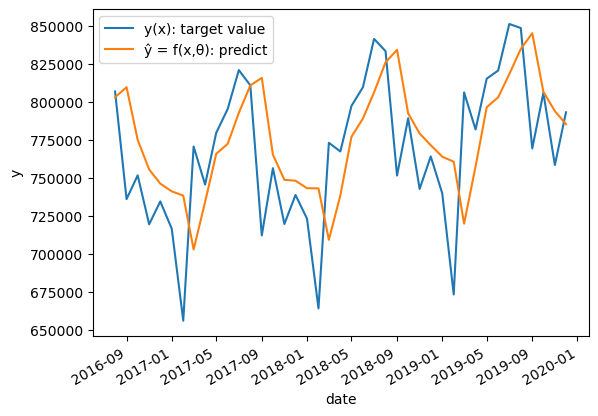

In [168]:
fig, ax = plt.subplots()
sns.lineplot(x=df_result['date'], y=df_result['y'], label='y(x): target value')
sns.lineplot(x=df_result['date'], y=df_result['ŷ = f(x,θ)'], label='ŷ = f(x,θ): predict')
fig.autofmt_xdate()

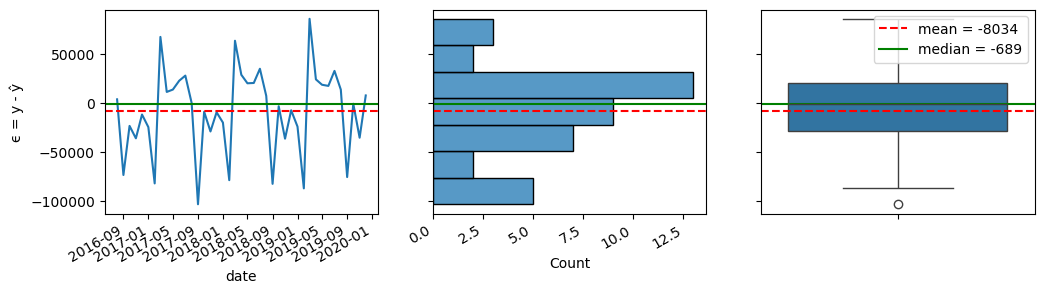

In [170]:
fig, (ax_plot, ax_hist, ax_box) = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 3))

mean = df_result['ϵ = y - ŷ'].mean()
median = df_result['ϵ = y - ŷ'].median()

sns.lineplot(x = df_result['date'], y = df_result['ϵ = y - ŷ'], ax=ax_plot)
ax_plot.axhline(mean, color='r', linestyle='--')
ax_plot.axhline(median, color='g', linestyle='-')

sns.histplot(y = df_result['ϵ = y - ŷ'], ax=ax_hist)
ax_hist.axhline(mean, color='r', linestyle='--', label='mean')
ax_hist.axhline(median, color='g', linestyle='-', label='median')

sns.boxplot(df_result['ϵ = y - ŷ'], ax=ax_box)
ax_box.axhline(mean, color='r', linestyle='--', label=f'mean = {mean:.0f}')
ax_box.axhline(median, color='g', linestyle='-', label=f'median = {median:.0f}')

fig.autofmt_xdate()
plt.legend(loc='upper right')

In [169]:
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score


# Calculate and print R^2 score.
r2 = r2_score(y_valid, y_pred)
print(f"R-squared: {r2:.4f}")

R-squared: 0.1347


In [159]:
mean_squared_error(y_valid, y_pred)

2211375841.8321657